# Interpretación de Clusters – Enfermedades Cardiacas
**Objetivo:** Caracterizar y comparar los dos clusters obtenidos en la etapa de clustering, utilizando todas las variables del estudio para generar una interpretación clínica y estadística.

## 1. Importaciones

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficas
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

## 2. Carga y revisión inicial de datos

In [19]:
# CORRECCIÓN: el nombre real del archivo usa guión bajo, no punto
df = pd.read_csv('P3_3_Interpretacion.csv')

# Estandarizar nombres de columnas
df.columns = df.columns.str.lower().str.strip()

# Convertir fecha
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

print('Dimensiones del dataset:', df.shape)
print('\nColumnas:')
print(df.columns.tolist())
print('\nValores faltantes por columna:')
print(df.isnull().sum())
print('\nCantidad de pacientes por cluster:')
print(df['cluster'].value_counts())
print('\nPorcentaje de pacientes por cluster:')
print((df['cluster'].value_counts(normalize=True) * 100).round(2))
if 'id' in df.columns:
    print(f'\nIDs duplicados: {df["id"].duplicated().sum()}')

Dimensiones del dataset: (297, 17)

Columnas:
['id', 'date', 'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'cluster']

Valores faltantes por columna:
id          0
date        0
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
cluster     0
dtype: int64

Cantidad de pacientes por cluster:
cluster
0    156
1    141
Name: count, dtype: int64

Porcentaje de pacientes por cluster:
cluster
0    52.53
1    47.47
Name: proportion, dtype: float64

IDs duplicados: 0


## 3. Definición de variables

In [20]:
variables_numericas = ['age','trestbps','chol','thalach','oldpeak','ca','num']
variables_categoricas = ['sex','cp','fbs','restecg','exang','slope','thal']

# Filtrar solo columnas presentes
variables_numericas = [c for c in variables_numericas if c in df.columns]
variables_categoricas = [c for c in variables_categoricas if c in df.columns]

etiquetas_cluster = {0: 'Cluster 0', 1: 'Cluster 1'}

diccionario_categorias = {
    'sex':     {0: 'Mujer', 1: 'Hombre'},
    'cp':      {1: 'Angina típica', 2: 'Angina atípica', 3: 'Dolor no anginal', 4: 'Sin dolor'},
    'fbs':     {0: 'Azúcar ≤120 mg/dl', 1: 'Azúcar >120 mg/dl'},
    'restecg': {0: 'Normal', 1: 'Onda ST-T anormal', 2: 'Hipertrofia ventricular'},
    'exang':   {0: 'No', 1: 'Sí'},
    'slope':   {1: 'Positiva', 2: 'Sin pendiente', 3: 'Negativa'},
    'thal':    {3: 'Normal', 6: 'Defecto fijo', 7: 'Defecto reversible'}
}

## 4. Resumen estadístico – Variables numéricas

In [21]:
resumen_numerico = df.groupby('cluster')[variables_numericas].agg(
    ['count','mean','median','std','min','max']
).round(2)

print('RESUMEN DE VARIABLES NUMÉRICAS POR CLUSTER')
print('=' * 60)
print(resumen_numerico.to_string())

RESUMEN DE VARIABLES NUMÉRICAS POR CLUSTER
          age                             trestbps                                  chol                                 thalach                                oldpeak                                 ca                              num                           
        count   mean median   std min max    count    mean median    std  min  max count    mean median    std  min  max   count    mean median    std min  max   count  mean median   std  min  max count  mean median   std min max count  mean median   std min max
cluster                                                                                                                                                                                                                                                               
0         156  53.55   54.5  9.40  29  76      156  130.85  130.0  17.19   94  180   156  214.26  214.0  32.89  126  417     156  150.96  155.0  22.97  71  202     156 

## 5. Diferencias entre clusters – Variables numéricas
Se usa la prueba no paramétrica de Mann-Whitney U (α = 0.05) dado que no se asume normalidad.

In [22]:
clusters = sorted(df['cluster'].dropna().unique())

if len(clusters) != 2:
    print('Este programa requiere exactamente 2 clusters.')
else:
    c0, c1 = clusters
    filas = []

    for var in variables_numericas:
        d0 = df[df['cluster'] == c0][var].dropna()
        d1 = df[df['cluster'] == c1][var].dropna()

        media_0, media_1 = d0.mean(), d1.mean()
        diferencia = media_1 - media_0
        std_comb = np.sqrt((d0.var() + d1.var()) / 2)
        diff_std = diferencia / std_comb if std_comb != 0 else np.nan

        try:
            _, p = mannwhitneyu(d0, d1, alternative='two-sided')
        except Exception:
            p = np.nan

        filas.append({
            'Variable': var,
            f'Media Cluster {c0}': round(media_0, 2),
            f'Media Cluster {c1}': round(media_1, 2),
            'Diferencia (C1−C0)': round(diferencia, 2),
            'Diferencia estandarizada': round(diff_std, 2),
            'p-value': round(p, 4),
            'Significativa (α=0.05)': 'Sí' if p < 0.05 else 'No'
        })

    diferencias_numericas = pd.DataFrame(filas)
    diferencias_numericas['|Diff. estand.|'] = diferencias_numericas['Diferencia estandarizada'].abs()
    diferencias_numericas = diferencias_numericas.sort_values('|Diff. estand.|', ascending=False)

    print('DIFERENCIAS NUMÉRICAS ENTRE CLUSTERS')
    print('=' * 60)
    print(diferencias_numericas.drop(columns='|Diff. estand.|').to_string(index=False))

DIFERENCIAS NUMÉRICAS ENTRE CLUSTERS
Variable  Media Cluster 0  Media Cluster 1  Diferencia (C1−C0)  Diferencia estandarizada  p-value Significativa (α=0.05)
    chol           214.26           283.96               69.71                      1.79   0.0000                     Sí
      ca             0.53             0.84                0.32                      0.34   0.0033                     Sí
     age            53.55            55.64                2.09                      0.23   0.0760                     No
     num             0.82             1.09                0.26                      0.22   0.0209                     Sí
 thalach           150.96           148.10               -2.86                     -0.12   0.2751                     No
trestbps           130.85           132.63                1.79                      0.10   0.6324                     No
 oldpeak             1.06             1.05               -0.01                     -0.01   0.9468                   

## 6. Visualización – Boxplots de variables numéricas

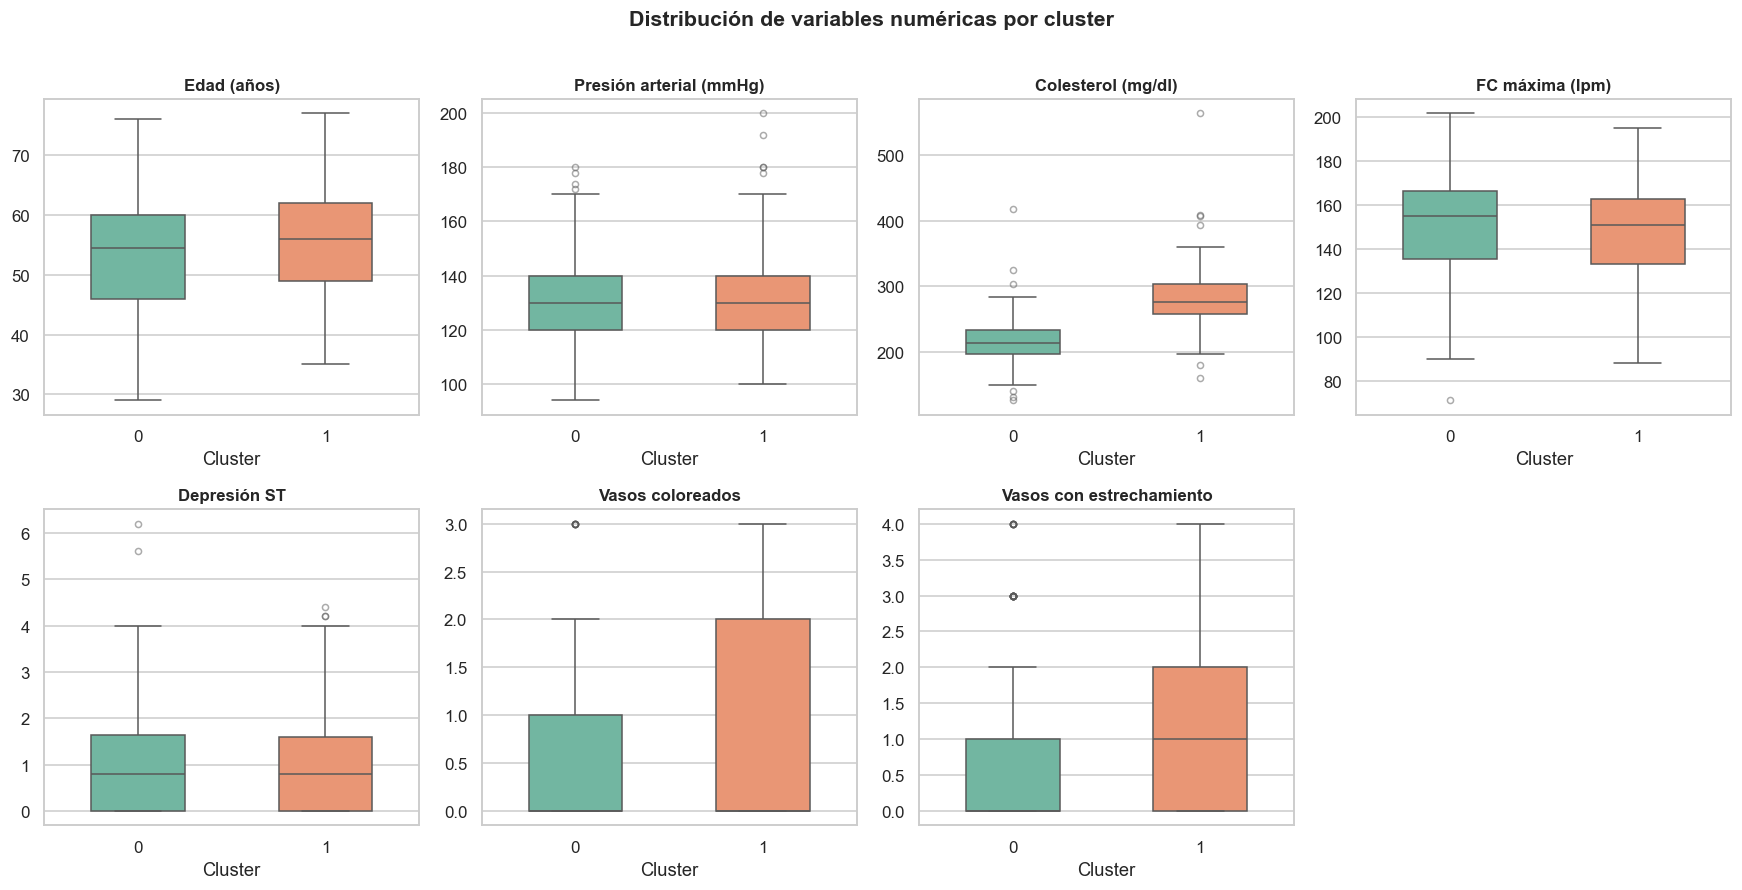

Figura guardada: boxplots_numericos.png


In [23]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

etiquetas_ejes = {
    'age': 'Edad (años)', 'trestbps': 'Presión arterial (mmHg)',
    'chol': 'Colesterol (mg/dl)', 'thalach': 'FC máxima (lpm)',
    'oldpeak': 'Depresión ST', 'ca': 'Vasos coloreados',
    'num': 'Vasos con estrechamiento'
}

for i, var in enumerate(variables_numericas):
    sns.boxplot(
        data=df, x='cluster', y=var, ax=axes[i],
        palette='Set2', width=0.5, flierprops=dict(marker='o', markersize=4, alpha=0.5)
    )
    axes[i].set_title(etiquetas_ejes.get(var, var), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('')

# Ocultar eje extra
axes[-1].set_visible(False)

fig.suptitle('Distribución de variables numéricas por cluster', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplots_numericos.png', bbox_inches='tight')
plt.show()
print('Figura guardada: boxplots_numericos.png')

## 7. Resumen y pruebas – Variables categóricas
Se usa la prueba chi-cuadrado de independencia (α = 0.05).

In [24]:
resultados_categoricos = []

for var in variables_categoricas:
    tabla_conteo = pd.crosstab(df[var], df['cluster'])
    tabla_pct = pd.crosstab(df[var], df['cluster'], normalize='columns') * 100

    if var in diccionario_categorias:
        mapping = diccionario_categorias[var]
        tabla_conteo.index = tabla_conteo.index.map(lambda x: mapping.get(x, x))
        tabla_pct.index = tabla_pct.index.map(lambda x: mapping.get(x, x))

    try:
        chi2, p, dof, _ = chi2_contingency(tabla_conteo)
    except Exception:
        p = np.nan

    sig = 'Sí' if p < 0.05 else 'No'
    resultados_categoricos.append({'Variable': var, 'p-value (χ²)': round(p, 4), 'Significativa (α=0.05)': sig})

    print(f'\n{" Variable: " + var.upper() + " ":─^55}')
    print('Conteo:')
    print(tabla_conteo.to_string())
    print('\nPorcentaje por cluster (%):')
    print(tabla_pct.round(2).to_string())
    print(f'  → p-value χ²: {p:.4f}  |  Diferencia significativa: {sig}')

resultados_categoricos_df = pd.DataFrame(resultados_categoricos)
print('\n\nRESUMEN PRUEBAS CHI-CUADRADO')
print('=' * 45)
print(resultados_categoricos_df.to_string(index=False))


──────────────────── Variable: SEX ────────────────────
Conteo:
cluster    0   1
sex             
Mujer     44  52
Hombre   112  89

Porcentaje por cluster (%):
cluster      0      1
sex                  
Mujer    28.21  36.88
Hombre   71.79  63.12
  → p-value χ²: 0.1411  |  Diferencia significativa: No

──────────────────── Variable: CP ─────────────────────
Conteo:
cluster            0   1
cp                      
Angina típica     17   6
Angina atípica    25  24
Dolor no anginal  47  36
Sin dolor         67  75

Porcentaje por cluster (%):
cluster               0      1
cp                            
Angina típica     10.90   4.26
Angina atípica    16.03  17.02
Dolor no anginal  30.13  25.53
Sin dolor         42.95  53.19
  → p-value χ²: 0.0917  |  Diferencia significativa: No

──────────────────── Variable: FBS ────────────────────
Conteo:
cluster              0    1
fbs                        
Azúcar ≤120 mg/dl  133  121
Azúcar >120 mg/dl   23   20

Porcentaje por cluster (%):
cl

## 8. Visualización – Distribución de variables categóricas

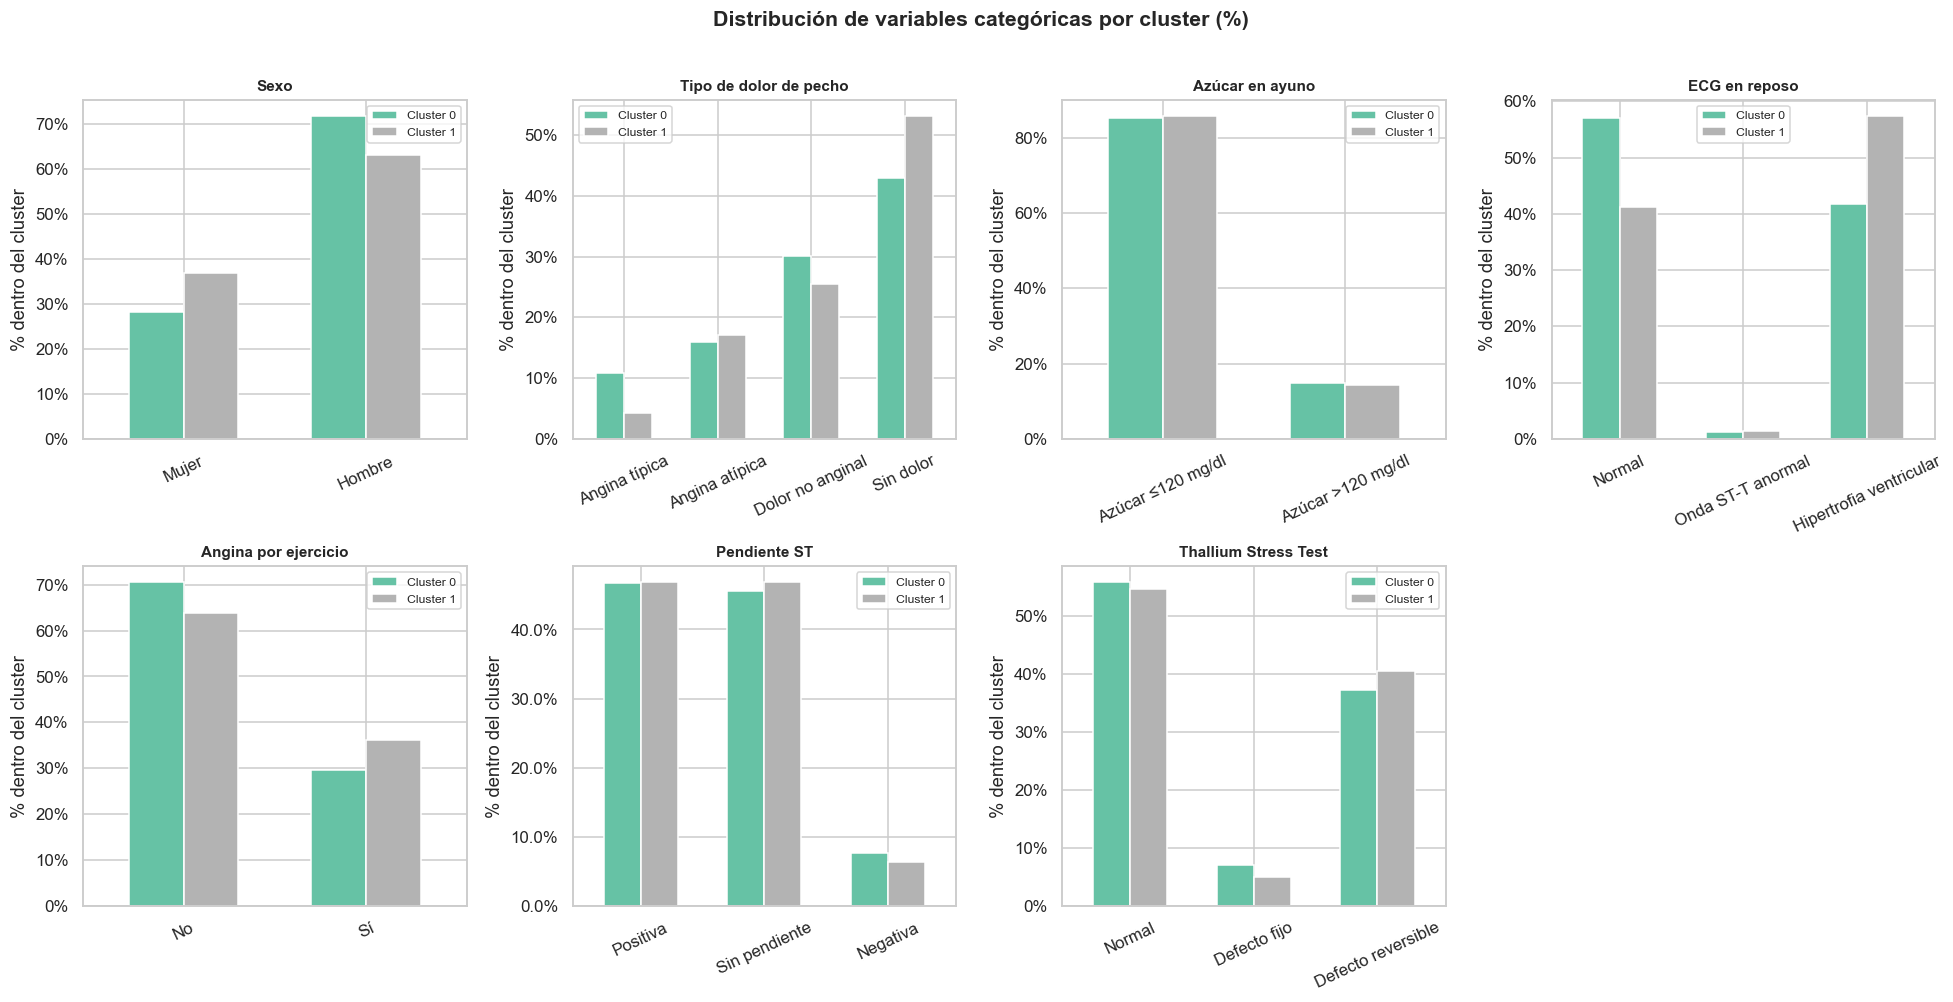

Figura guardada: barras_categoricas.png


In [25]:
titulos = {
    'sex': 'Sexo', 'cp': 'Tipo de dolor de pecho',
    'fbs': 'Azúcar en ayuno', 'restecg': 'ECG en reposo',
    'exang': 'Angina por ejercicio', 'slope': 'Pendiente ST',
    'thal': 'Thallium Stress Test'
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, var in enumerate(variables_categoricas):
    tabla = pd.crosstab(df[var], df['cluster'], normalize='columns') * 100
    if var in diccionario_categorias:
        tabla.index = tabla.index.map(lambda x: diccionario_categorias[var].get(x, x))
    tabla.columns = [f'Cluster {c}' for c in tabla.columns]

    tabla.plot(kind='bar', ax=axes[i], rot=25, width=0.6, colormap='Set2', edgecolor='white')
    axes[i].set_title(titulos.get(var, var), fontsize=10, fontweight='bold')
    axes[i].set_ylabel('% dentro del cluster')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter())

axes[-1].set_visible(False)
fig.suptitle('Distribución de variables categóricas por cluster (%)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('barras_categoricas.png', bbox_inches='tight')
plt.show()
print('Figura guardada: barras_categoricas.png')

## 9. Distribución temporal por cluster

Cantidad de estudios por año y cluster:
      Cluster 0  Cluster 1
year                      
2000          6          7
2001          7          7
2002          5          5
2003          5          5
2004         11         10
2005          8          4
2006          8          6
2007          9          8
2008          9          6
2009          6          6
2010          7          5
2011          6          4
2012          7         10
2013          6          7
2014          5          7
2015          5          7
2016          9          6
2017          8          5
2018          6         11
2019         11          8
2020         12          7


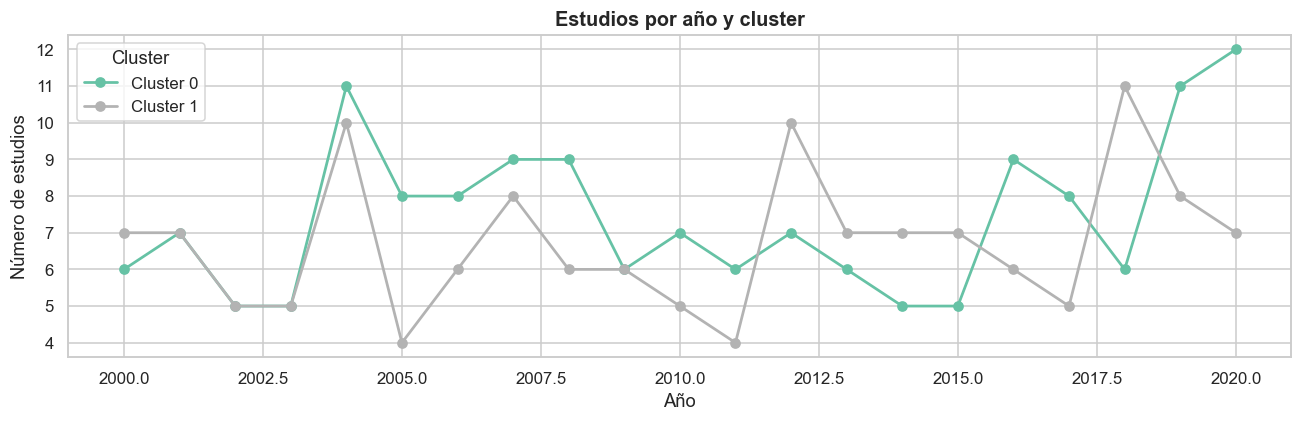

Figura guardada: temporal_clusters.png


In [26]:
if 'date' in df.columns:
    df['year'] = df['date'].dt.year
    tabla_year = pd.crosstab(df['year'], df['cluster'])
    tabla_year.columns = [f'Cluster {c}' for c in tabla_year.columns]

    print('Cantidad de estudios por año y cluster:')
    print(tabla_year.to_string())

    # Gráfica de línea temporal
    fig, ax = plt.subplots(figsize=(12, 4))
    tabla_year.plot(ax=ax, marker='o', linewidth=1.8, colormap='Set2')
    ax.set_title('Estudios por año y cluster', fontsize=13, fontweight='bold')
    ax.set_xlabel('Año')
    ax.set_ylabel('Número de estudios')
    ax.legend(title='Cluster')
    plt.tight_layout()
    plt.savefig('temporal_clusters.png', bbox_inches='tight')
    plt.show()
    print('Figura guardada: temporal_clusters.png')

## 10. Perfil resumen de cada cluster
Consolidación de los hallazgos más relevantes de cada cluster.

In [27]:
print('=' * 60)
print('PERFIL RESUMEN DE CLUSTERS')
print('=' * 60)

for c in clusters:
    sub = df[df['cluster'] == c]
    n = len(sub)
    print(f'\n─── CLUSTER {c} (n={n}) ────────────────────────────────')

    # Numéricas
    for var in variables_numericas:
        m = sub[var].mean()
        s = sub[var].std()
        print(f'  {var:<12}: media={m:.2f}  ±{s:.2f}')

    # Categóricas
    for var in variables_categoricas:
        moda_code = sub[var].mode()[0]
        pct = (sub[var] == moda_code).mean() * 100
        etiq = diccionario_categorias.get(var, {}).get(moda_code, str(moda_code))
        print(f'  {var:<12}: moda={etiq!r} ({pct:.1f}%)')

print('\n' + '=' * 60)

PERFIL RESUMEN DE CLUSTERS

─── CLUSTER 0 (n=156) ────────────────────────────────
  age         : media=53.55  ±9.40
  trestbps    : media=130.85  ±17.19
  chol        : media=214.26  ±32.89
  thalach     : media=150.96  ±22.97
  oldpeak     : media=1.06  ±1.18
  ca          : media=0.53  ±0.85
  num         : media=0.82  ±1.23
  sex         : moda='Hombre' (71.8%)
  cp          : moda='Sin dolor' (42.9%)
  fbs         : moda='Azúcar ≤120 mg/dl' (85.3%)
  restecg     : moda='Normal' (57.1%)
  exang       : moda='No' (70.5%)
  slope       : moda='Positiva' (46.8%)
  thal        : moda='Normal' (55.8%)

─── CLUSTER 1 (n=141) ────────────────────────────────
  age         : media=55.64  ±8.55
  trestbps    : media=132.63  ±18.39
  chol        : media=283.96  ±44.14
  thalach     : media=148.10  ±22.90
  oldpeak     : media=1.05  ±1.16
  ca          : media=0.84  ±1.01
  num         : media=1.09  ±1.23
  sex         : moda='Hombre' (63.1%)
  cp          : moda='Sin dolor' (53.2%)
  fbs   

## 11. Exportación de resultados a Excel

In [28]:
import openpyxl

with pd.ExcelWriter('interpretacion_clusters.xlsx', engine='openpyxl') as writer:

    # Hoja 1: resumen numérico
    resumen_numerico.to_excel(writer, sheet_name='resumen_numerico')

    # Hoja 2: diferencias numéricas
    if len(clusters) == 2:
        diferencias_numericas.drop(columns='|Diff. estand.|', errors='ignore').to_excel(
            writer, sheet_name='diferencias_numericas', index=False
        )

    # Hoja 3: pruebas chi-cuadrado
    resultados_categoricos_df.to_excel(writer, sheet_name='categoricas_chi2', index=False)

    # Hoja 4: distribución temporal
    if 'year' in df.columns:
        tabla_year.to_excel(writer, sheet_name='distribucion_temporal')

    # Hoja 5: datos completos con etiquetas
    df_export = df.copy()
    for var, mapa in diccionario_categorias.items():
        if var in df_export.columns:
            df_export[var + '_label'] = df_export[var].map(mapa)
    df_export.to_excel(writer, sheet_name='datos_con_etiquetas', index=False)

print('Archivo generado: interpretacion_clusters.xlsx')

Archivo generado: interpretacion_clusters.xlsx
